In [57]:
import numpy as np
import pandas as pd
import os
from scipy.stats import entropy

In [58]:
# Directories and systems
base_dir = "/Users/jlee295/cenp/CAFEMOL/analyses/EtD"
systems = [
    "H3","cenpa",
    "ltH3core","ltcenpacore",
    "thruhelixH3","thruhelixcenpa",
    "H3withcenpahelix","cenpawithH3helix",
    "stH3core","stcenpacore",
    "H3withcenpalatch","cenpawithH3latch",
    "H3withcenpa_latch_helix","cenpawithH3_latch_helix",
    "exnotailH3","exnotailcenpa"
]

# Load distance files
def load_distances(system, side):
    path = os.path.join(base_dir, f"{system}-dist-etd_{side}.dat")
    data = np.loadtxt(path, comments="#")
    if data.ndim > 1:
        return data[:,1]
    else:
        return data

H3_entry = load_distances("H3","entry")
H3_exit  = load_distances("H3","exit")
CENPA_entry = load_distances("cenpa","entry")
CENPA_exit  = load_distances("cenpa","exit")

# Histogram bins
all_data = np.concatenate([H3_entry,H3_exit,CENPA_entry,CENPA_exit])
bins = np.linspace(all_data.min(), all_data.max(), 100)

# Probability distribution
def prob_dist(data):
    hist,_ = np.histogram(data, bins=bins, density=True)
    hist += 1e-12
    hist /= np.sum(hist)
    return hist

p_H3_entry = prob_dist(H3_entry)
p_H3_exit  = prob_dist(H3_exit)
p_CENPA_entry = prob_dist(CENPA_entry)
p_CENPA_exit  = prob_dist(CENPA_exit)

# Split replicas
def split_replicas(data):
    n = len(data)//4
    return [
        data[0:n],
        data[n:2*n],
        data[2*n:3*n],
        data[3*n:4*n]
    ]

# KL calculation
results = []

for sys in systems:
    entry = load_distances(sys,"entry")
    exit  = load_distances(sys,"exit")

    p_entry = prob_dist(entry)
    p_exit  = prob_dist(exit)

    KL_H3_entry = entropy(p_entry,p_H3_entry)
    KL_H3_exit  = entropy(p_exit,p_H3_exit)
    KL_CENPA_entry = entropy(p_entry,p_CENPA_entry)
    KL_CENPA_exit  = entropy(p_exit,p_CENPA_exit)

    KL_H3_avg = (KL_H3_entry + KL_H3_exit)/2
    KL_CENPA_avg = (KL_CENPA_entry + KL_CENPA_exit)/2

    entry_reps = split_replicas(entry)
    exit_reps  = split_replicas(exit)

    KL_H3_rep = []
    KL_CENPA_rep = []

    for r in range(4):
        p_entry_r = prob_dist(entry_reps[r])
        p_exit_r  = prob_dist(exit_reps[r])

        KL_H3_r = (entropy(p_entry_r,p_H3_entry) + entropy(p_exit_r,p_H3_exit))/2
        KL_CENPA_r = (entropy(p_entry_r,p_CENPA_entry) + entropy(p_exit_r,p_CENPA_exit))/2

        KL_H3_rep.append(KL_H3_r)
        KL_CENPA_rep.append(KL_CENPA_r)

    KL_H3_std = np.std(KL_H3_rep, ddof=1)
    KL_CENPA_std = np.std(KL_CENPA_rep, ddof=1)

    results.append([
        sys,
        KL_H3_avg, KL_H3_std,
        KL_CENPA_avg, KL_CENPA_std
    ])

# Build dataframe
df = pd.DataFrame(
    results,
    columns=[
        "System",
        "KL_H3_avg","KL_H3_std",
        "KL_CENPA_avg","KL_CENPA_std"
    ]
)

# Normalize KL averages (0-1)
H3_min,H3_max = df["KL_H3_avg"].min(), df["KL_H3_avg"].max()
C_min,C_max   = df["KL_CENPA_avg"].min(), df["KL_CENPA_avg"].max()

df["KL_H3_norm"] = (df["KL_H3_avg"] - H3_min) / (H3_max - H3_min)
df["KL_CENPA_norm"] = (df["KL_CENPA_avg"] - C_min) / (C_max - C_min)

# Scale errors relative to the normalization range
df["KL_H3_std_norm"] = df["KL_H3_std"] / (H3_max - H3_min)
df["KL_CENPA_std_norm"] = df["KL_CENPA_std"] / (C_max - C_min)

# Similarity score: 0 = H3-like, 1 = CENP-A-like
df["similarity_H3_to_CENPA"] = (
    df["KL_H3_norm"] / (df["KL_H3_norm"] + df["KL_CENPA_norm"])
)

# Similarity including scaled error
df["similarity_H3_to_CENPA_with_error"] = (
    (df["KL_H3_norm"] + df["KL_H3_std_norm"]) /
    (df["KL_H3_norm"] + df["KL_H3_std_norm"] + df["KL_CENPA_norm"] + df["KL_CENPA_std_norm"])
)

# Save
outfile = os.path.join("/Users/jlee295/cenp/CAFEMOL/analyses/KLdivergence_EtD","KL_divergence_with_error.tsv")
df.to_csv(outfile, sep="\t", index=False)

print(df)

                     System  KL_H3_avg  KL_H3_std  KL_CENPA_avg  KL_CENPA_std  \
0                        H3   0.000000   0.000335      2.312466      0.016521   
1                     cenpa   2.528112   0.130085      0.000000      0.008545   
2                  ltH3core   1.495407   0.727702      0.306142      0.309459   
3               ltcenpacore   2.690442   0.788702      0.075308      0.056562   
4               thruhelixH3   1.925011   0.709973      0.222431      0.158194   
5            thruhelixcenpa   0.909073   1.275689      0.661565      0.749601   
6          H3withcenpahelix   0.688594   0.366355      0.698603      0.320785   
7          cenpawithH3helix   2.752629   0.706205      0.030334      0.055884   
8                  stH3core   0.608542   0.332909      0.948857      0.356774   
9               stcenpacore   2.391202   0.857861      0.038107      0.185917   
10         H3withcenpalatch   3.208248   0.056701      0.094853      0.018967   
11         cenpawithH3latch 

/var/folders/kb/jkhhkfp92jbgryf8vwdhfn7h0000gn/T/ipykernel_35267/4128011801.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = get_cmap("tab20")


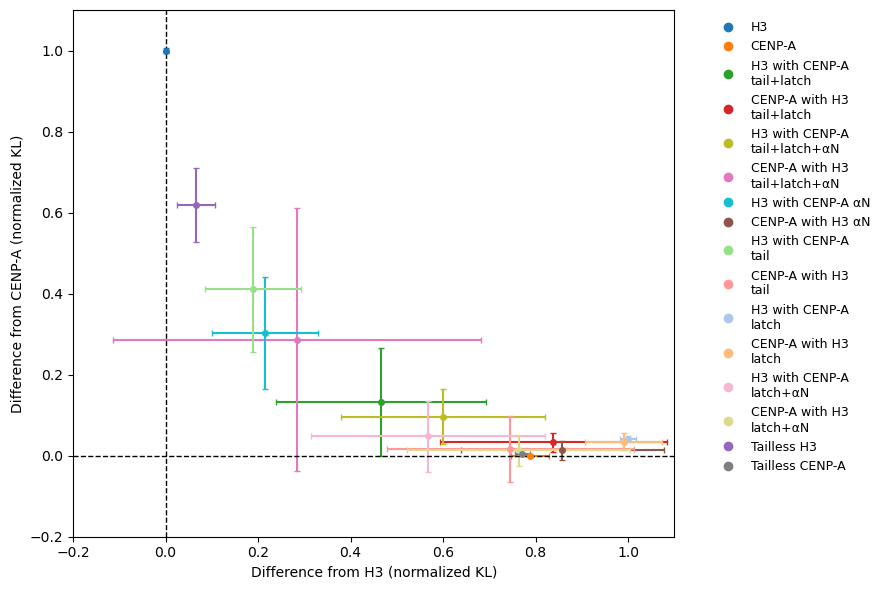

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib.lines import Line2D

tab20 = get_cmap("tab20")

# system name mapping + colors
systems = {
    "H3": ("H3", tab20(0)),
    "exnotailH3": ("Tailless H3", tab20(8)),
    "cenpa": ("CENP-A", tab20(2)),
    "exnotailcenpa": ("Tailless CENP-A", tab20(14)),
    "H3withcenpahelix": ("H3 with CENP-A \u03B1N", tab20(18)),
    "H3withcenpa_latch_helix": ("H3 with CENP-A\nlatch+\u03B1N", tab20(13)),
    "cenpawithH3helix": ("CENP-A with H3 \u03B1N", tab20(10)),
    "cenpawithH3_latch_helix": ("CENP-A with H3\nlatch+\u03B1N", tab20(17)),
    "H3withcenpalatch": ("H3 with CENP-A\nlatch", tab20(1)),
    "ltH3core": ("H3 with CENP-A\ntail+latch", tab20(4)),
    "cenpawithH3latch": ("CENP-A with H3\nlatch", tab20(3)),
    "ltcenpacore": ("CENP-A with H3\ntail+latch", tab20(6)),
    "stH3core": ("H3 with CENP-A\ntail", tab20(5)),
    "thruhelixH3": ("H3 with CENP-A\ntail+latch+\u03B1N", tab20(16)),
    "stcenpacore": ("CENP-A with H3\ntail", tab20(7)),
    "thruhelixcenpa": ("CENP-A with H3\ntail+latch+\u03B1N", tab20(12)),
}

# load normalized KL data
df = pd.read_csv("KL_divergence_with_error.tsv", sep="\t")

fig, ax = plt.subplots(figsize=(9,6))

for _, row in df.iterrows():
    system = row["System"]
    if system not in systems:
        continue

    label, color = systems[system]

    x = row["KL_H3_norm"]
    y = row["KL_CENPA_norm"]

    # use normalized errors
    xerr = row["KL_H3_std_norm"]
    yerr = row["KL_CENPA_std_norm"]

    ax.errorbar(x, y, xerr=xerr, yerr=yerr, fmt="o", color=color, markersize=4, capsize=2)

# axis labels
ax.set_xlabel("Difference from H3 (normalized KL)")
ax.set_ylabel("Difference from CENP-A (normalized KL)")

# axis limits
ax.set_xlim(-0.2,1.1)
ax.set_ylim(-0.2,1.1)

ax.axvline(0, color='k', linestyle='--', lw=1)
ax.axhline(0, color='k', linestyle='--', lw=1)

# create a clean legend with only colored markers (no error bars)
handles = []
for system in df["System"]:
    if system not in systems:
        continue
    label, color = systems[system]
    handles.append(Line2D([0], [0], marker='o', color=color, linestyle='', markersize=6, label=label))

ax.legend(handles=handles, bbox_to_anchor=(1.05, 1), loc="upper left", frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig("KL_similarity_plot.pdf")
plt.show()